In [21]:
import pandas as pd
import numpy as np

In [22]:
train_df = pd.read_csv(r"C:\Users\Administrator\Desktop\Codveda Technologies\Data Set For Task\Churn Prdiction Data\churn-bigml-80.csv")
test_df  = pd.read_csv(r"C:\Users\Administrator\Desktop\Codveda Technologies\Data Set For Task\Churn Prdiction Data\churn-bigml-20.csv")


In [23]:
df = pd.concat([train_df, test_df], ignore_index=True)

# Merge both files into one complete dataset

In [24]:
print("Shape:", df.shape)

Shape: (3333, 20)


In [25]:
print("\nColumns:", list(df.columns))


Columns: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


In [26]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [27]:
print("\nData Types:")
print(df.dtypes)





Data Types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


In [28]:
print(df.isnull().sum())
#total missing value

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [29]:

print(df['Churn'].value_counts())
print("\nChurn Distribution:")

Churn
False    2850
True      483
Name: count, dtype: int64

Churn Distribution:


## converting boolean to int(0,1) ##

In [30]:
# Convert Churn from bool to int (True=1, False=0)
df['Churn'] = df['Churn'].astype(int)

# Verify
print("Churn after conversion:")
print(df['Churn'].value_counts())

Churn after conversion:
Churn
0    2850
1     483
Name: count, dtype: int64


## Separate Target aur Features ##

In [31]:
# Drop unnecessary columns
# Charge columns are derived from minutes columns
# Area code has no relation with churn
# Separate target variable
y = df['Churn']

# Drop Churn + unnecessary columns together
cols_to_drop = [
    'Churn',
    'Total day charge',
    'Total eve charge',
    'Total night charge',
    'Total intl charge',
    'Area code'
]

X = df.drop(columns=cols_to_drop)


print("Columns after dropping:")
print(list(X.columns))
print("\nNew shape:", X.shape)

Columns after dropping:
['State', 'Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls']

New shape: (3333, 14)


## Categorical Encoding ##

In [32]:
# Convert Yes/No columns to 1/0
X['International plan'] = X['International plan'].map({'Yes': 1, 'No': 0})
X['Voice mail plan'] = X['Voice mail plan'].map({'Yes': 1, 'No': 0})



In [33]:
print(X['International plan'].value_counts())

International plan
0    3010
1     323
Name: count, dtype: int64


In [34]:
print(X['Voice mail plan'].value_counts())


Voice mail plan
0    2411
1     922
Name: count, dtype: int64


### label encoding (because multiple value we have in state column)###

In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
le = LabelEncoder()

In [37]:
# Fit and transform State column
X['State'] = le.fit_transform(X['State'])


In [38]:
print(X['State'].value_counts().sort_index().head(10))
print("\nUnique states:", X['State'].nunique())

State
0    52
1    80
2    55
3    64
4    34
5    66
6    74
7    54
8    61
9    63
Name: count, dtype: int64

Unique states: 51


## Standardization ##

In [39]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler



In [40]:
scaler = StandardScaler()

In [41]:
# Fit and transform all columns
X_scaled = scaler.fit_transform(X)

In [42]:
print(df['Total day minutes'].describe())

count    3333.000000
mean      179.775098
std        54.467389
min         0.000000
25%       143.700000
50%       179.400000
75%       216.400000
max       350.800000
Name: Total day minutes, dtype: float64


In [43]:
print(pd.DataFrame(X_scaled, columns=X.columns)['Total day minutes'].describe().round(3))

count    3333.000
mean       -0.000
std         1.000
min        -3.301
25%        -0.662
50%        -0.007
75%         0.673
max         3.140
Name: Total day minutes, dtype: float64


## Train/Test Split! ##

In [44]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split data into 80% train and 20% test

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y # class balance maintaince
     
)

In [46]:
print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

X_train shape: (2666, 14)
X_test  shape: (667, 14)
y_train shape: (2666,)
y_test  shape: (667,)


## Model Traning ##

In [47]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression


In [56]:
# Create model object
# max_iter=1000 

model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [50]:
# Get feature names
feature_names = X.columns

# Create dataframe of coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

In [57]:
 #Sort by coefficient value
coef_df = coef_df.sort_values('Coefficient', ascending=False)


print("Feature Coefficients:")
print(coef_df.to_string(index=False))

Feature Coefficients:
               Feature  Coefficient
     Total day minutes     0.722956
    International plan     0.629920
Customer service calls     0.592932
 Number vmail messages     0.529491
     Total eve minutes     0.412391
    Total intl minutes     0.247790
   Total night minutes     0.191832
       Total eve calls     0.039304
        Account length     0.023487
                 State     0.022042
       Total day calls     0.020123
     Total night calls    -0.006290
      Total intl calls    -0.174915
       Voice mail plan    -0.938764


In [58]:
# Predict class (0 or 1)
y_pred = model.predict(X_test)

# Predict probability
y_pred_prob = model.predict_proba(X_test)[:, 1]


In [59]:
# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_pred_prob.round(2)
})

print("Actual vs Predicted (first 10 rows):")
print(comparison.head(10))

Actual vs Predicted (first 10 rows):
   Actual  Predicted  Probability
0       1          1         0.57
1       0          0         0.23
2       0          0         0.11
3       0          0         0.15
4       0          0         0.15
5       0          1         0.60
6       0          0         0.11
7       0          0         0.13
8       0          1         0.76
9       0          0         0.12


## Evaluation ##

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Calculate metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)


In [61]:
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Accuracy  : 0.7811
Precision : 0.3793
Recall    : 0.7938

Detailed Report:
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       570
           1       0.38      0.79      0.51        97

    accuracy                           0.78       667
   macro avg       0.67      0.79      0.69       667
weighted avg       0.87      0.78      0.81       667



## Confusion Matrix and ploting  ##

In [62]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


In [63]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)


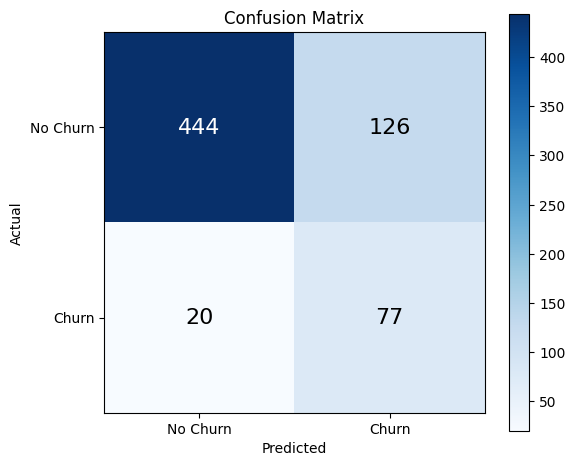

TN = 444 → No Churn sahi pakde
FP = 126 → No Churn ko Churn bola
FN = 20 → Churn miss ho gaye
TP = 77 → Churn sahi pakde


In [71]:

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_yticklabels(['No Churn', 'Churn'])

# Numbers inside boxes
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                fontsize=16, color='white' if cm[i,j] > 200 else 'black')

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


print(f"TN = {cm[0,0]} → No Churn sahi pakde")
print(f"FP = {cm[0,1]} → No Churn ko Churn bola")
print(f"FN = {cm[1,0]} → Churn miss ho gaye")
print(f"TP = {cm[1,1]} → Churn sahi pakde")

## ROC CURVE ##

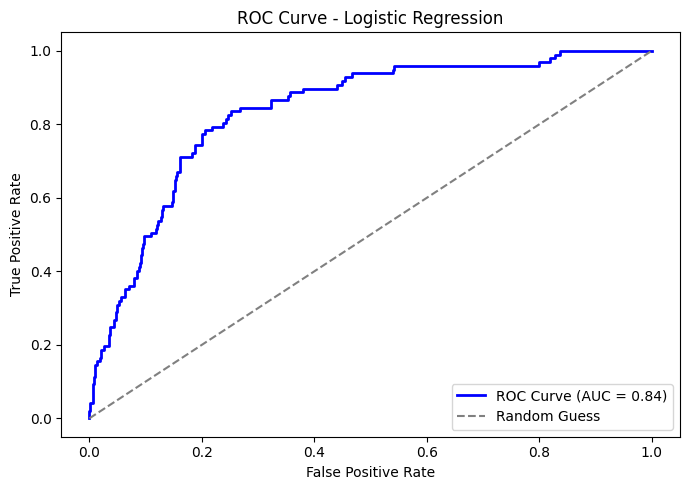

AUC Score: 0.8366


In [72]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 5))

# Model curve
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')

# Random guess line
plt.plot([0, 1], [0, 1], color='grey',
         linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [73]:
print("=" * 45)
print("   LOGISTIC REGRESSION - SUMMARY")
print("=" * 45)
print(f" Dataset     : Churn Prediction")
print(f" Total Rows  : 3333")
print(f" Features    : 14")
print(f" Train/Test  : 80% / 20%")
print("-" * 45)
print(f" Accuracy    : {accuracy:.2f}")
print(f" Precision   : {precision:.2f}")
print(f" Recall      : {recall:.2f}")
print(f" AUC Score   : {roc_auc:.2f}")
print("-" * 45)
print(f" TN = {cm[0,0]}  FP = {cm[0,1]}")
print(f" FN = {cm[1,0]}   TP = {cm[1,1]}")
print("=" * 45)
print(" Task Complete!")


   LOGISTIC REGRESSION - SUMMARY
 Dataset     : Churn Prediction
 Total Rows  : 3333
 Features    : 14
 Train/Test  : 80% / 20%
---------------------------------------------
 Accuracy    : 0.78
 Precision   : 0.38
 Recall      : 0.79
 AUC Score   : 0.84
---------------------------------------------
 TN = 444  FP = 126
 FN = 20   TP = 77
 Task Complete!
